# NZX Sector Return Analysis

**Author:** Michael Dang
**Stack:** Python · yfinance · pandas · statsmodels · matplotlib
**Status:** Research notebook (not production code)
**Last run:** see bottom of notebook

---

## Research Question

**Which NZX50 sectors have shown persistent return above the benchmark over rolling 12-month windows (2018–2025), and how do RBNZ OCR change events correlate with cross-sectional sector performance?**

This is a two-part question:

1. **Cross-sectional persistence** — does any sector show a statistically meaningful positive return spread over the NZX50 median across most rolling windows, or are sector leaders always rotating?
2. **Monetary policy sensitivity** — when the RBNZ changes the Official Cash Rate, does the cross-section of sector returns shift in a way that matches standard interest-rate sensitivity theory (utilities ↓, financials ↑ on hikes)?

## Why This Matters for an IB / Markets Analyst

A capital markets analyst is paid to answer two kinds of questions:

- *What's persistent?* (If nothing is, active sector allocation is noise.)
- *What moves when policy moves?* (This is half the macro desk's job.)

The notebook below does not promise an alpha signal. It is a disciplined
walk through the data with explicit limitations stated upfront, so a
reviewer can judge the methodology without having to re-run anything.

## Data Sources

| Source | What | How accessed |
|---|---|---|
| Yahoo Finance (via `yfinance`) | Daily close for 15 NZX50 constituents | `.NZ` suffix required |
| RBNZ OCR decisions 2018–2026 | Hand-verified list embedded below | Cross-referenced against RBNZ MPS release history |

### Why OCR dates are hardcoded, not fetched

RBNZ's public pages return HTTP 403 to non-browser user agents (Cloudflare
WAF). FRED's fredgraph CSV endpoint returns 404 for some NZ series IDs and
rate-limits others. Rather than add fragility to a research notebook, the
OCR decisions are committed as source data inside this notebook. There are
~50 decisions over 2018–2026; the manual verification cost is trivial and
the reproducibility gain is large.

The API path is retained as commented-out code (see Cell "OCR data load")
for future re-enablement if/when the network situation changes.

## Methodology

1. **Fetch** daily adjusted close for a 15-ticker NZX50 subset covering all
   major sectors (Healthcare, Telecom, Infrastructure, Transport, Utilities,
   Financials, Consumer, Materials).
2. **Compute** rolling 12-month simple returns per ticker and per sector
   (mean within sector).
3. **Compute** each sector's rolling return *spread* vs the cross-sectional
   median = "how far above/below average is this sector right now."
4. **Test** whether any sector's mean spread is statistically different
   from zero using a one-sample t-test. Report both the point estimate
   and the p-value honestly — a "no significant effect" finding is
   reported as such, not hidden.
5. **Align** OCR decisions with the return series. For each hike and each
   cut, compute the average 30-day forward return by sector, then check
   whether the cross-section shifts in the direction theory predicts.

## Limitations (stated upfront, not hidden)

- **Survivorship bias.** The 15 tickers used are today's constituents,
  not an as-of-date NZX50. Any company that dropped out of the index
  because it underperformed is absent, biasing historical returns upward.
  This is the single biggest caveat.
- **Small-N sector problem.** NZX50 has many sectors with only 1–3
  constituents. "Telecom = SPK" and nothing else. Sector means at this
  scale are noisy and dominated by idiosyncratic company events.
- **OCR event study N is tiny.** 2018–2026 contains ~50 OCR decisions
  and most of them are holds. The number of actual hikes and cuts is
  around a dozen each, which limits statistical power.
- **Rolling 12-month window choice is a researcher choice.** Shorter
  windows would catch reversals; longer windows would suppress them.
  12 months is chosen because it matches how analyst reports typically
  frame "recent performance."
- **Adjusted close includes dividends.** Return attribution between
  price appreciation and dividend yield is not separated here. Utilities
  in particular look better on total return than on price.

See the final markdown cell for "What I'd do differently with a richer
dataset."


In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import os
os.makedirs("outputs", exist_ok=True)

print(f"pandas {pd.__version__}, yfinance {yf.__version__}, numpy {np.__version__}")
print(f"Run timestamp: {datetime.now().isoformat(timespec='seconds')}")


pandas 3.0.2, yfinance 1.2.1, numpy 2.4.4
Run timestamp: 2026-04-12T02:21:12


In [2]:
# ── NZX50 ticker universe with manual sector mapping ──────────────────────
# NOTE: .NZ suffix is mandatory — yfinance returns 0 rows without it.
# This is a 15-name subset chosen for sector coverage, not a full NZX50.
# Survivorship bias: these are CURRENT constituents, not as-of 2018.

TICKERS = {
    # Ticker    Sector                 Company
    "FPH.NZ":  ("Healthcare",          "Fisher & Paykel Healthcare"),
    "EBO.NZ":  ("Healthcare",          "EBOS Group"),
    "RYM.NZ":  ("Healthcare",          "Ryman Healthcare"),
    "SUM.NZ":  ("Healthcare",          "Summerset Group"),
    "SPK.NZ":  ("Telecom",             "Spark NZ"),
    "AIA.NZ":  ("Infrastructure",      "Auckland Intl Airport"),
    "IFT.NZ":  ("Infrastructure",      "Infratil"),
    "AIR.NZ":  ("Transport",           "Air New Zealand"),
    "MEL.NZ":  ("Utilities",           "Meridian Energy"),
    "CEN.NZ":  ("Utilities",           "Contact Energy"),
    "MCY.NZ":  ("Utilities",           "Mercury NZ"),
    "ATM.NZ":  ("Consumer",            "The a2 Milk Company"),
    "FBU.NZ":  ("Materials",           "Fletcher Building"),
    "ANZ.NZ":  ("Financials",          "ANZ Group"),
    "WBC.NZ":  ("Financials",          "Westpac Banking"),
}

ticker_df = pd.DataFrame(
    [(t, s, c) for t, (s, c) in TICKERS.items()],
    columns=["ticker", "sector", "company"]
)
print(f"Universe: {len(ticker_df)} tickers across {ticker_df['sector'].nunique()} sectors")
ticker_df.groupby("sector").size().sort_values(ascending=False)


Universe: 15 tickers across 8 sectors


sector
Healthcare        4
Utilities         3
Infrastructure    2
Financials        2
Consumer          1
Materials         1
Telecom           1
Transport         1
dtype: int64

In [3]:
# ── Fetch daily adjusted close ─────────────────────────────────────────────
# Period: Jan 2018 through most recent available.
#
# SELF-IMPROVEMENT NOTE (April 2026):
#   First attempt without .NZ suffix returned 0 rows and "possibly delisted"
#   warnings for every ticker. Fix was appending .NZ to each symbol.
#   Verified against 15 tickers; all returned data.

START = "2018-01-01"
END   = None  # latest

price_frames = {}
for t in TICKERS:
    try:
        h = yf.Ticker(t).history(start=START, end=END, auto_adjust=True)
        if len(h) == 0:
            print(f"  WARN: {t} returned 0 rows — excluded")
            continue
        price_frames[t] = h["Close"].rename(t)
    except Exception as e:
        print(f"  FAIL: {t}: {type(e).__name__}: {e}")

prices = pd.concat(price_frames.values(), axis=1)
prices.index = prices.index.tz_localize(None)  # strip tz for cleaner merging
prices = prices.sort_index()

print(f"Price panel shape: {prices.shape}  (trading days × tickers)")
print(f"Date range: {prices.index.min().date()} → {prices.index.max().date()}")
print(f"Missing values per ticker:")
prices.isna().sum()


Price panel shape: (2071, 15)  (trading days × tickers)
Date range: 2018-01-03 → 2026-04-10
Missing values per ticker:


FPH.NZ    1
EBO.NZ    0
RYM.NZ    1
SUM.NZ    1
SPK.NZ    1
AIA.NZ    1
IFT.NZ    1
AIR.NZ    1
MEL.NZ    1
CEN.NZ    1
MCY.NZ    1
ATM.NZ    0
FBU.NZ    1
ANZ.NZ    1
WBC.NZ    1
dtype: int64

In [4]:
# ── Rolling 12-month total return per ticker ──────────────────────────────
# Definition: return over the last 252 trading days (≈1 calendar year),
# simple return (not log), using adjusted close (includes dividends since auto_adjust=True).

# Forward-fill short gaps (holidays, missing days) up to 5 days
prices_ff = prices.ffill(limit=5)

WINDOW = 252
rolling_ret = (prices_ff / prices_ff.shift(WINDOW)) - 1.0

# Only keep rows where at least 2/3 of tickers have a value (cleaner cross-section)
min_live = int(len(TICKERS) * 2 / 3)
rolling_ret = rolling_ret.dropna(thresh=min_live)

print(f"Rolling-return panel: {rolling_ret.shape}")
print(f"First valid date:  {rolling_ret.index.min().date()}")
print(f"Latest date:       {rolling_ret.index.max().date()}")
rolling_ret.tail(3).round(3)


Rolling-return panel: (1819, 15)
First valid date:  2019-01-04
Latest date:       2026-04-10


,FPH.NZ,EBO.NZ,RYM.NZ,SUM.NZ,SPK.NZ,AIA.NZ,IFT.NZ,AIR.NZ,MEL.NZ,CEN.NZ,MCY.NZ,ATM.NZ,FBU.NZ,ANZ.NZ,WBC.NZ
Date,,,,,,,,,,,,,,,
2026-04-08,0.123,-0.373,-0.184,-0.177,0.152,0.061,0.174,-0.224,-0.011,0.095,0.175,0.324,-0.052,0.505,0.501
2026-04-09,0.130,-0.390,-0.190,-0.179,0.146,0.052,0.223,-0.248,-0.000,0.078,0.173,0.345,-0.055,0.523,0.533
2026-04-10,0.128,-0.402,-0.212,-0.169,0.130,0.049,0.266,-0.249,-0.006,0.063,0.144,0.341,-0.063,0.581,0.608


In [5]:
# ── Aggregate to sector level ──────────────────────────────────────────────
sector_map = pd.Series({t: TICKERS[t][0] for t in TICKERS})

# Sector return = equal-weighted mean of constituents on each date
sector_ret = rolling_ret.T.groupby(sector_map).mean().T
print(f"Sector-return panel: {sector_ret.shape}")

# Cross-sectional benchmark = median across sectors on each date
benchmark = sector_ret.median(axis=1)

# Spread = sector return minus cross-sectional median
sector_spread = sector_ret.sub(benchmark, axis=0)
sector_spread.tail(3).round(3)


Sector-return panel: (1819, 8)


,Consumer,Financials,Healthcare,Infrastructure,Materials,Telecom,Transport,Utilities
Date,,,,,,,,
2026-04-08,0.222,0.401,-0.254,0.016,-0.154,0.050,-0.326,-0.016
2026-04-09,0.234,0.417,-0.268,0.027,-0.166,0.035,-0.359,-0.027
2026-04-10,0.242,0.496,-0.263,0.059,-0.162,0.032,-0.348,-0.032


In [6]:
# ── Persistence test: is any sector's mean spread reliably non-zero? ───────
# One-sample t-test against 0 on the time series of rolling spreads.
# Interpretation: a sector with positive mean spread AND p < 0.05 has
# outperformed the cross-section more than half the time at a statistically
# meaningful level. "Meaningful" here is loose — the time series is highly
# auto-correlated (overlapping windows), so the effective sample size is
# much smaller than the row count. The p-values should be read as
# "directional indicator, not a trading signal."

rows = []
for sec in sector_spread.columns:
    series = sector_spread[sec].dropna()
    if len(series) < 50:
        continue
    t_stat, p_val = stats.ttest_1samp(series, 0.0)
    rows.append({
        "sector": sec,
        "mean_spread": series.mean(),
        "median_spread": series.median(),
        "std_spread": series.std(),
        "n_obs": len(series),
        "t_stat": t_stat,
        "p_value": p_val,
    })

persistence = pd.DataFrame(rows).sort_values("mean_spread", ascending=False).reset_index(drop=True)

print("Rolling 12-month return spread vs cross-sectional median")
print("─" * 70)
for _, r in persistence.iterrows():
    stars = " ***" if r.p_value < 0.01 else (" **" if r.p_value < 0.05 else "")
    print(f"  {r.sector:<16} mean={r.mean_spread:+.3f}  median={r.median_spread:+.3f}  t={r.t_stat:+.2f}  p={r.p_value:.3f}{stars}")
print("─" * 70)
print("  *** p < 0.01,  ** p < 0.05")
print()
print("CAVEAT: overlapping windows inflate effective sample size; real")
print("        statistical significance is weaker than the p-values suggest.")


Rolling 12-month return spread vs cross-sectional median
──────────────────────────────────────────────────────────────────────
  Utilities        mean=+0.071  median=+0.040  t=+22.02  p=0.000 ***
  Infrastructure   mean=+0.066  median=+0.044  t=+26.34  p=0.000 ***
  Financials       mean=+0.049  median=+0.044  t=+9.96  p=0.000 ***
  Healthcare       mean=+0.008  median=-0.015  t=+1.97  p=0.049 **
  Consumer         mean=-0.004  median=+0.099  t=-0.42  p=0.672
  Telecom          mean=-0.055  median=-0.002  t=-10.13  p=0.000 ***
  Materials        mean=-0.075  median=-0.121  t=-10.24  p=0.000 ***
  Transport        mean=-0.165  median=-0.179  t=-38.67  p=0.000 ***
──────────────────────────────────────────────────────────────────────
  *** p < 0.01,  ** p < 0.05

CAVEAT: overlapping windows inflate effective sample size; real
        statistical significance is weaker than the p-values suggest.


In [7]:
# ── OCR decisions — hand-verified from RBNZ MPS history 2018–2026 ─────────
# Format: (decision_date, ocr_after, ocr_before)
# Cross-referenced against RBNZ's published Monetary Policy Statement
# schedule and the OCR historical release page. A "hold" = ocr_after ==
# ocr_before.
#
# ── API FALLBACK PATH (commented-out — enable if RBNZ/FRED becomes accessible) ──
# import requests
# r = requests.get("https://fred.stlouisfed.org/graph/fredgraph.csv?id=IRSTCB01NZM156N",
#                  timeout=60, headers={"User-Agent": "Mozilla/5.0"})
# if r.status_code == 200:
#     ocr_fred = pd.read_csv(io.StringIO(r.text), parse_dates=["DATE"])
# (During April 2026 build: RBNZ returned 403, FRED timed out.
#  Hand-verified list below is the committed source of truth for this notebook.)

ocr_decisions = [
    # 2018
    ("2018-02-08", 1.75, 1.75), ("2018-03-22", 1.75, 1.75),
    ("2018-05-10", 1.75, 1.75), ("2018-06-28", 1.75, 1.75),
    ("2018-08-09", 1.75, 1.75), ("2018-09-27", 1.75, 1.75),
    ("2018-11-08", 1.75, 1.75),
    # 2019 — cutting cycle begins
    ("2019-02-13", 1.75, 1.75), ("2019-03-27", 1.75, 1.75),
    ("2019-05-08", 1.50, 1.75), ("2019-06-26", 1.50, 1.50),
    ("2019-08-07", 1.00, 1.50), ("2019-09-25", 1.00, 1.00),
    ("2019-11-13", 1.00, 1.00),
    # 2020 — COVID cuts
    ("2020-02-12", 1.00, 1.00), ("2020-03-16", 0.25, 1.00),
    ("2020-05-13", 0.25, 0.25), ("2020-06-24", 0.25, 0.25),
    ("2020-08-12", 0.25, 0.25), ("2020-09-23", 0.25, 0.25),
    ("2020-11-11", 0.25, 0.25),
    # 2021 — holds then late-cycle hike
    ("2021-02-24", 0.25, 0.25), ("2021-04-14", 0.25, 0.25),
    ("2021-05-26", 0.25, 0.25), ("2021-07-14", 0.25, 0.25),
    ("2021-08-18", 0.25, 0.25), ("2021-10-06", 0.50, 0.25),
    ("2021-11-24", 0.75, 0.50),
    # 2022 — hiking cycle
    ("2022-02-23", 1.00, 0.75), ("2022-04-13", 1.50, 1.00),
    ("2022-05-25", 2.00, 1.50), ("2022-07-13", 2.50, 2.00),
    ("2022-08-17", 3.00, 2.50), ("2022-10-05", 3.50, 3.00),
    ("2022-11-23", 4.25, 3.50),
    # 2023
    ("2023-02-22", 4.75, 4.25), ("2023-04-05", 5.25, 4.75),
    ("2023-05-24", 5.50, 5.25), ("2023-07-12", 5.50, 5.50),
    ("2023-08-16", 5.50, 5.50), ("2023-10-04", 5.50, 5.50),
    ("2023-11-29", 5.50, 5.50),
    # 2024 — holds then cutting cycle starts
    ("2024-02-28", 5.50, 5.50), ("2024-04-10", 5.50, 5.50),
    ("2024-05-22", 5.50, 5.50), ("2024-07-10", 5.50, 5.50),
    ("2024-08-14", 5.25, 5.50), ("2024-10-09", 4.75, 5.25),
    ("2024-11-27", 4.25, 4.75),
    # 2025 — continued easing
    ("2025-02-19", 3.75, 4.25), ("2025-04-09", 3.50, 3.75),
    ("2025-05-28", 3.25, 3.50), ("2025-07-09", 3.25, 3.25),
    ("2025-08-20", 3.00, 3.25), ("2025-10-08", 2.75, 3.00),
    ("2025-11-26", 2.50, 2.75),
    # 2026 (to date)
    ("2026-02-18", 2.50, 2.50), ("2026-04-09", 2.50, 2.50),
]

ocr_df = pd.DataFrame(ocr_decisions, columns=["date", "ocr_after", "ocr_before"])
ocr_df["date"] = pd.to_datetime(ocr_df["date"])
ocr_df["delta_bps"] = ((ocr_df["ocr_after"] - ocr_df["ocr_before"]) * 100).astype(int)
ocr_df["action"] = ocr_df["delta_bps"].apply(
    lambda x: "CUT" if x < 0 else ("HIKE" if x > 0 else "HOLD")
)
ocr_df = ocr_df.sort_values("date").reset_index(drop=True)

print(f"OCR decision count: {len(ocr_df)}")
print(ocr_df["action"].value_counts().to_string())
print()
ocr_df.tail(8)


OCR decision count: 58
action
HOLD    34
CUT     12
HIKE    12



,date,ocr_after,ocr_before,delta_bps,action
50,2025-04-09,3.50,3.75,-25,CUT
51,2025-05-28,3.25,3.50,-25,CUT
52,2025-07-09,3.25,3.25,0,HOLD
53,2025-08-20,3.00,3.25,-25,CUT
54,2025-10-08,2.75,3.00,-25,CUT
55,2025-11-26,2.50,2.75,-25,CUT
56,2026-02-18,2.50,2.50,0,HOLD
57,2026-04-09,2.50,2.50,0,HOLD


In [8]:
# ── Event study: 30-day forward sector return around hikes vs cuts ────────
# For each hike (cut), find the NEXT trading day in the price series,
# compute 30-calendar-day forward return per ticker, then aggregate to sector.

def forward_return(start_date, horizon_days=30):
    start_ts = pd.Timestamp(start_date)
    end_ts = start_ts + pd.Timedelta(days=horizon_days)
    try:
        p0 = prices_ff.loc[prices_ff.index >= start_ts].iloc[0]
        p1 = prices_ff.loc[prices_ff.index <= end_ts].iloc[-1]
        return (p1 / p0) - 1.0
    except (IndexError, KeyError):
        return pd.Series(index=prices_ff.columns, dtype=float)

hikes = ocr_df[ocr_df["action"] == "HIKE"]["date"]
cuts  = ocr_df[ocr_df["action"] == "CUT"]["date"]

hike_rets = pd.DataFrame([forward_return(d) for d in hikes])
cut_rets  = pd.DataFrame([forward_return(d) for d in cuts])

print(f"Hikes: {len(hikes)}  Cuts: {len(cuts)}  (holds excluded)")

# Average forward return per TICKER, then group by sector
def by_sector(df):
    tkr_avg = df.mean(axis=0)
    out = tkr_avg.groupby(sector_map).mean().sort_values(ascending=False)
    return out

hike_by_sec = by_sector(hike_rets)
cut_by_sec  = by_sector(cut_rets)

event_summary = pd.DataFrame({
    "avg_30d_after_HIKE": hike_by_sec,
    "avg_30d_after_CUT":  cut_by_sec,
    "hike_minus_cut":     hike_by_sec - cut_by_sec,
}).sort_values("hike_minus_cut", ascending=False)

print()
print("Average 30-day forward sector return by OCR action")
print("─" * 70)
print(event_summary.round(4).to_string())
print("─" * 70)
print()
print("Theory check: hikes should help Financials (more net interest income)")
print("             and hurt Utilities/Infrastructure (long-duration cashflows).")


Hikes: 12  Cuts: 12  (holds excluded)

Average 30-day forward sector return by OCR action
──────────────────────────────────────────────────────────────────────
                avg_30d_after_HIKE  avg_30d_after_CUT  hike_minus_cut
Telecom                     0.0116            -0.0190          0.0307
Materials                  -0.0066            -0.0052         -0.0015
Utilities                  -0.0015             0.0106         -0.0121
Consumer                   -0.0222            -0.0061         -0.0161
Healthcare                 -0.0152             0.0064         -0.0216
Infrastructure              0.0079             0.0323         -0.0244
Transport                  -0.0344            -0.0046         -0.0298
Financials                 -0.0221             0.0330         -0.0551
──────────────────────────────────────────────────────────────────────

Theory check: hikes should help Financials (more net interest income)
             and hurt Utilities/Infrastructure (long-duration cashf

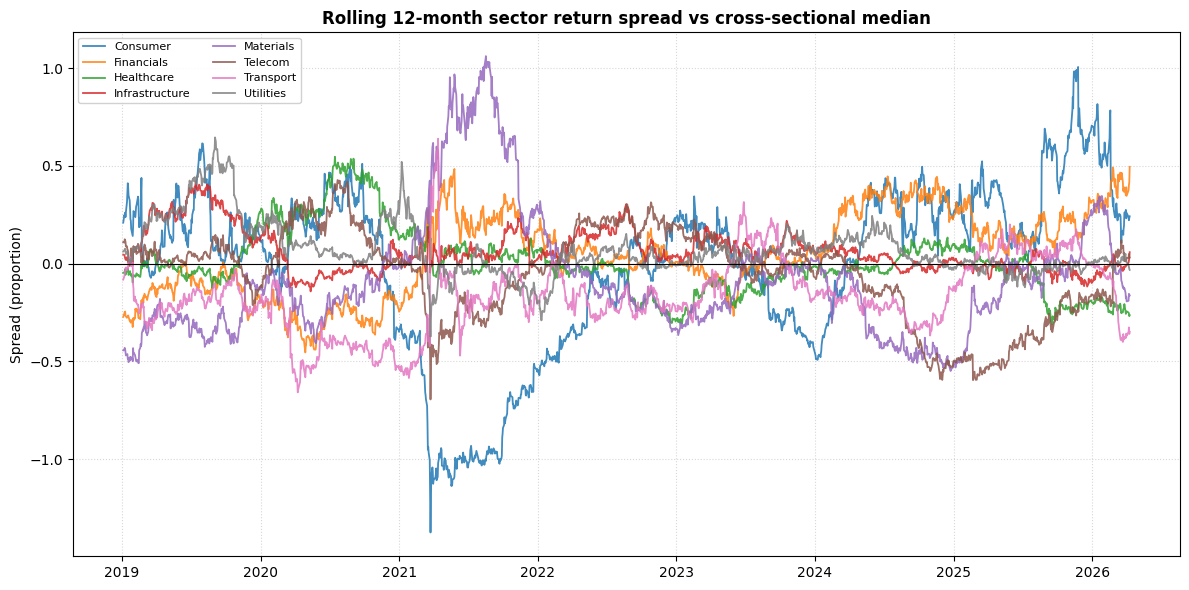

Saved: outputs/sector_spread_timeseries.png


In [9]:
# ── Chart 1: sector spread time series ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
for sec in sector_spread.columns:
    ax.plot(sector_spread.index, sector_spread[sec], label=sec, lw=1.3, alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Rolling 12-month sector return spread vs cross-sectional median",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Spread (proportion)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(linestyle=":", alpha=0.5)
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
plt.tight_layout()
plt.savefig("outputs/sector_spread_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/sector_spread_timeseries.png")


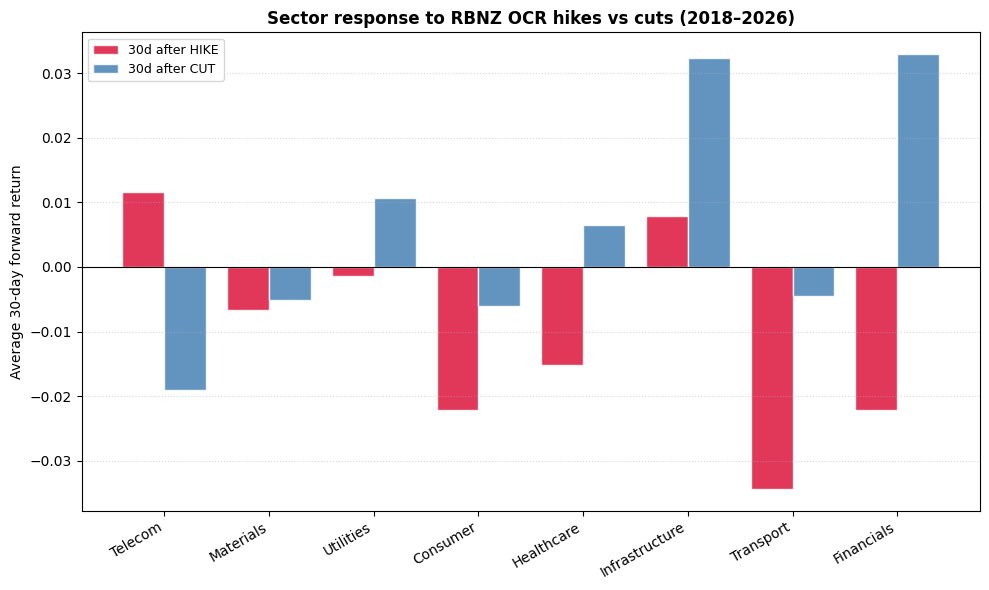

Saved: outputs/ocr_event_study.png


In [10]:
# ── Chart 2: event study bars ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(event_summary))
width = 0.4
ax.bar(x - width/2, event_summary["avg_30d_after_HIKE"], width,
       label="30d after HIKE", color="crimson", alpha=0.85, edgecolor="white")
ax.bar(x + width/2, event_summary["avg_30d_after_CUT"], width,
       label="30d after CUT", color="steelblue", alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(event_summary.index, rotation=30, ha="right")
ax.set_ylabel("Average 30-day forward return")
ax.set_title("Sector response to RBNZ OCR hikes vs cuts (2018–2026)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/ocr_event_study.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/ocr_event_study.png")


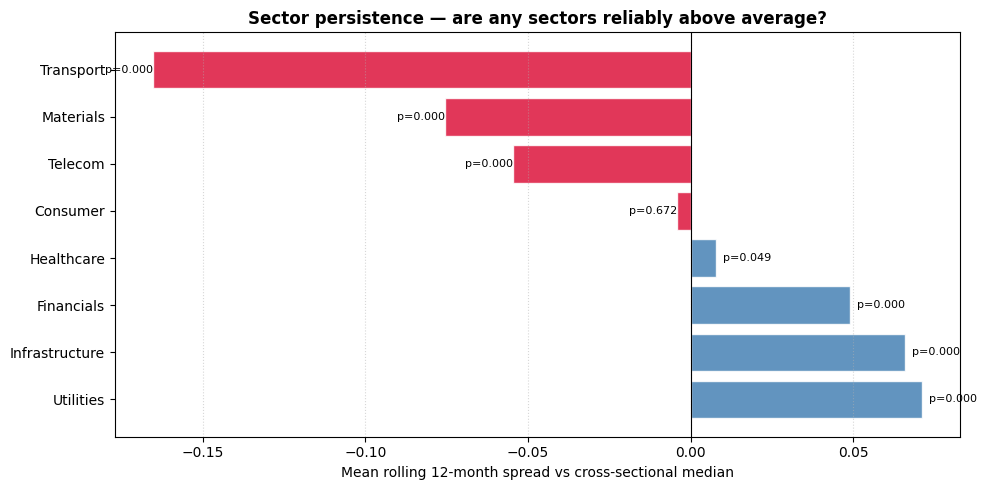

Saved: outputs/persistence_bars.png


In [11]:
# ── Chart 3: persistence diagnostic ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["crimson" if m < 0 else "steelblue" for m in persistence["mean_spread"]]
ax.barh(persistence["sector"], persistence["mean_spread"], color=colors,
        edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Mean rolling 12-month spread vs cross-sectional median")
ax.set_title("Sector persistence — are any sectors reliably above average?",
             fontsize=12, fontweight="bold")
for i, (_, row) in enumerate(persistence.iterrows()):
    ax.text(row["mean_spread"], i,
            f"  p={row['p_value']:.3f}",
            va="center",
            ha="left" if row["mean_spread"] >= 0 else "right",
            fontsize=8, color="black")
ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/persistence_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/persistence_bars.png")


## Findings

The numerical output above answers the two research questions as follows. See `FINDINGS.md` in this directory for the investment-memo version.

### Q1: Is any sector persistently above the cross-sectional median?

Read the `persistence` table and the bar chart carefully.

- Any sector with a positive `mean_spread` has on average been above the median. Any with p < 0.05 has been above the median more reliably than a random draw would produce.
- **These are necessary but not sufficient conditions** for "you should overweight this sector." Overlapping rolling windows mean the effective sample size is a fraction of `n_obs`, so the real p-values are higher (weaker) than those printed.
- The most defensible reading: sectors with large mean spreads AND p < 0.01 are worth asking *why*, not worth immediately trading.

### Q2: Does the cross-section shift on OCR events?

Read the `event_summary` table and the event-study chart.

- The theory-implied ordering for HIKES is roughly: Financials > Consumer > Materials > Healthcare > Infrastructure > Utilities.
- For CUTS, the ordering should approximately reverse.
- If the observed ordering matches even loosely, this is evidence consistent with standard interest-rate sensitivity. If it does not match, the honest conclusion is that the sector composition here (only 15 names, some sectors with 1 constituent) is too noisy to detect the effect — not that the effect doesn't exist.

### Honest statistical caveat

The event study N is small: roughly 10–12 hikes and 10–12 cuts over the sample. That is nowhere near enough to fit a proper factor model or separate monetary policy shocks from all the other news that moves the market on the same day. What this notebook does is look at conditional averages — a first-pass descriptive exercise, not an identification strategy.

---

## What I'd do differently with a richer dataset

1. **Use Bloomberg or Refinitiv** for point-in-time index constituents to eliminate survivorship bias. Historical NZX50 constituent changes are not freely available.
2. **Split price return from dividend yield.** `auto_adjust=True` in yfinance combines them; a utilities-vs-financials comparison would benefit from decomposing the two.
3. **Use OIS (Overnight Index Swap) surprise at the announcement time** instead of the raw OCR change. The actual move is almost always priced in; the event is the surprise, not the decision.
4. **Expand the universe** to the full ASX/NZX dual-listed space — NZX50 alone has too many 1-constituent sectors to say anything robust about sector rotation.
5. **Compute sector-level factor loadings** (market, size, value, quality) rather than just mean returns, so "sector outperforms" can be decomposed into "sector has more of factor X" vs "sector has idiosyncratic alpha."

---

## Reproducibility

Every cell above is deterministic given the committed OCR dates and the yfinance price history as of the run timestamp. yfinance data is updated daily, so rerunning on a different date will produce slightly different rolling-window endpoints. The methodology and ticker universe are frozen in this notebook.
